<a href="https://colab.research.google.com/github/ujju2020/ujju2020/blob/main/marketing_campaign_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(" Libraries imported successfully!")
print(" Marketing Campaign Analysis Ready")

 Libraries imported successfully!
 Marketing Campaign Analysis Ready


## Step 1: Data Import and Initial Examination

In [2]:
# Load the dataset
df = pd.read_csv('marketing_data.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (2240, 28)

Column Names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Country']

First 5 rows:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,SP


In [3]:
# Examine Dt_Customer and Income variables
print("=== Dt_Customer Analysis ===")
print("Data type:", df['Dt_Customer'].dtype)
print("Sample values:")
print(df['Dt_Customer'].head(10))
print("Unique values count:", df['Dt_Customer'].nunique())

print("\n=== Income Analysis ===")
print("Data type:", df[' Income '].dtype)
print("Sample values:")
print(df[' Income '].head(10))
print("Missing values:", df[' Income '].isnull().sum())
print("Unique values count:", df[' Income '].nunique())

=== Dt_Customer Analysis ===
Data type: object
Sample values:
0    6/16/14
1    6/15/14
2    5/13/14
3    5/11/14
4     4/8/14
5    3/17/14
6    1/29/14
7    1/18/14
8    1/11/14
9    1/11/14
Name: Dt_Customer, dtype: object
Unique values count: 663

=== Income Analysis ===
Data type: object
Sample values:
0    $84,835.00 
1    $57,091.00 
2    $67,267.00 
3    $32,474.00 
4    $21,474.00 
5    $71,691.00 
6    $63,564.00 
7    $44,931.00 
8    $65,324.00 
9    $65,324.00 
Name:  Income , dtype: object
Missing values: 24
Unique values count: 1974


In [4]:
# Data info and basic statistics
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null

,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Step 2: Data Cleaning and Missing Value Imputation

In [5]:
# Clean income column - remove $ signs and convert to numeric
df['Income_Clean'] = df[' Income '].str.replace('$', '').str.replace(',', '')
df['Income_Clean'] = pd.to_numeric(df['Income_Clean'], errors='coerce')

print("Income after cleaning:")
print("Missing values:", df['Income_Clean'].isnull().sum())
print("Data type:", df['Income_Clean'].dtype)
print("Sample values:", df['Income_Clean'].head())

Income after cleaning:
Missing values: 24
Data type: float64
Sample values: 0    84835.0
1    57091.0
2    67267.0
3    32474.0
4    21474.0
Name: Income_Clean, dtype: float64


In [6]:
# Examine education and marital status categories
print("=== Education Categories ===")
print(df['Education'].value_counts())
print("\n=== Marital Status Categories ===")
print(df['Marital_Status'].value_counts())

# Clean education categories
df['Education_Clean'] = df['Education'].replace({
    '2n Cycle': 'Undergraduate',
    'Basic': 'High School',
    'Graduation': 'Bachelor',
    'Master': 'Master',
    'PhD': 'PhD'
})

# Clean marital status categories
df['Marital_Status_Clean'] = df['Marital_Status'].replace({
    'Married': 'Married',
    'Together': 'Married',  # Combine similar categories
    'Single': 'Single',
    'Divorced': 'Single',   # Combine similar categories
    'Widow': 'Single',      # Combine similar categories
    'Alone': 'Single',
    'Absurd': 'Single',     # Clean unusual entries
    'YOLO': 'Single'        # Clean unusual entries
})

print("\n=== Cleaned Categories ===")
print("Education:", df['Education_Clean'].value_counts())
print("\nMarital Status:", df['Marital_Status_Clean'].value_counts())

=== Education Categories ===
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

=== Marital Status Categories ===
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64

=== Cleaned Categories ===
Education: Education_Clean
Bachelor         1127
PhD               486
Master            370
Undergraduate     203
High School        54
Name: count, dtype: int64

Marital Status: Marital_Status_Clean
Married    1444
Single      796
Name: count, dtype: int64


In [7]:
# Impute missing income values based on education and marital status
print("=== Income Imputation Analysis ===")

# Calculate median income by education and marital status
income_by_groups = df.groupby(['Education_Clean', 'Marital_Status_Clean'])['Income_Clean'].agg(['median', 'count']).round(2)
print("Median income by Education and Marital Status:")
print(income_by_groups)

# Impute missing values
for education in df['Education_Clean'].unique():
    for marital in df['Marital_Status_Clean'].unique():
        mask = (df['Education_Clean'] == education) & (df['Marital_Status_Clean'] == marital) & (df['Income_Clean'].isnull())
        if mask.sum() > 0:
            # Get median income for this group
            group_median = df[(df['Education_Clean'] == education) &
                             (df['Marital_Status_Clean'] == marital) &
                             (df['Income_Clean'].notna())]['Income_Clean'].median()

            if pd.notna(group_median):
                df.loc[mask, 'Income_Clean'] = group_median
                print(f"Imputed {mask.sum()} values for {education}-{marital} with median ${group_median:,.0f}")

# Check remaining missing values
print(f"\nRemaining missing income values: {df['Income_Clean'].isnull().sum()}")

# If any remaining, use overall median
if df['Income_Clean'].isnull().sum() > 0:
    overall_median = df['Income_Clean'].median()
    df['Income_Clean'].fillna(overall_median, inplace=True)
    print(f"Filled remaining with overall median: ${overall_median:,.0f}")

=== Income Imputation Analysis ===
Median income by Education and Marital Status:
                                       median  count
Education_Clean Marital_Status_Clean                
Bachelor        Married               51763.5    714
                Single                52372.5    402
High School     Married               23179.0     34
                Single                16383.0     20
Master          Married               50920.5    240
                Single                51124.0    125
PhD             Married               57004.5    306
                Single                52278.0    175
Undergraduate   Married               46219.0    136
                Single                48470.5     64
Imputed 6 values for Bachelor-Single with median $52,372
Imputed 5 values for Bachelor-Married with median $51,764
Imputed 2 values for PhD-Single with median $52,278
Imputed 3 values for PhD-Married with median $57,004
Imputed 1 values for Undergraduate-Single with median $48,470


## Step 3: Feature Engineering

In [8]:
# Convert Dt_Customer to datetime and calculate age
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%m/%d/%y')
current_year = 2025  # Using current year
df['Age'] = current_year - df['Year_Birth']

# Total number of children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Total spending on products
product_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[product_columns].sum(axis=1)

# Total purchases across all channels
purchase_columns = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_columns].sum(axis=1)

# Additional useful features
df['Customer_Tenure_Days'] = (datetime(2025, 11, 22) - df['Dt_Customer']).dt.days
df['Avg_Purchase_Value'] = np.where(df['Total_Purchases'] > 0,
                                    df['Total_Spending'] / df['Total_Purchases'], 0)

# Campaign acceptance rate
campaign_columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['Total_Campaigns_Accepted'] = df[campaign_columns].sum(axis=1)

print("=== New Features Created ===")
new_features = ['Age', 'Total_Children', 'Total_Spending', 'Total_Purchases',
               'Customer_Tenure_Days', 'Avg_Purchase_Value', 'Total_Campaigns_Accepted']

for feature in new_features:
    print(f"{feature}: {df[feature].describe().round(2).to_dict()}")

=== New Features Created ===
Age: {'count': 2240.0, 'mean': 56.19, 'std': 11.98, 'min': 29.0, '25%': 48.0, '50%': 55.0, '75%': 66.0, 'max': 132.0}
Total_Children: {'count': 2240.0, 'mean': 0.95, 'std': 0.75, 'min': 0.0, '25%': 0.0, '50%': 1.0, '75%': 1.0, 'max': 3.0}
Total_Spending: {'count': 2240.0, 'mean': 605.8, 'std': 602.25, 'min': 5.0, '25%': 68.75, '50%': 396.0, '75%': 1045.5, 'max': 2525.0}
Total_Purchases: {'count': 2240.0, 'mean': 12.54, 'std': 7.21, 'min': 0.0, '25%': 6.0, '50%': 12.0, '75%': 18.0, 'max': 32.0}
Customer_Tenure_Days: {'count': 2240.0, 'mean': 4517.58, 'std': 202.12, 'min': 4164.0, '25%': 4344.75, '50%': 4519.5, '75%': 4693.0, 'max': 4863.0}
Avg_Purchase_Value: {'count': 2240.0, 'mean': 38.1, 'std': 45.91, 'min': 0.0, '25%': 13.0, '50%': 29.64, '75%': 49.14, 'max': 1679.0}
Total_Campaigns_Accepted: {'count': 2240.0, 'mean': 0.45, 'std': 0.89, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 1.0, 'max': 5.0}


## Step 4: Exploratory Data Analysis - Distributions and Outliers

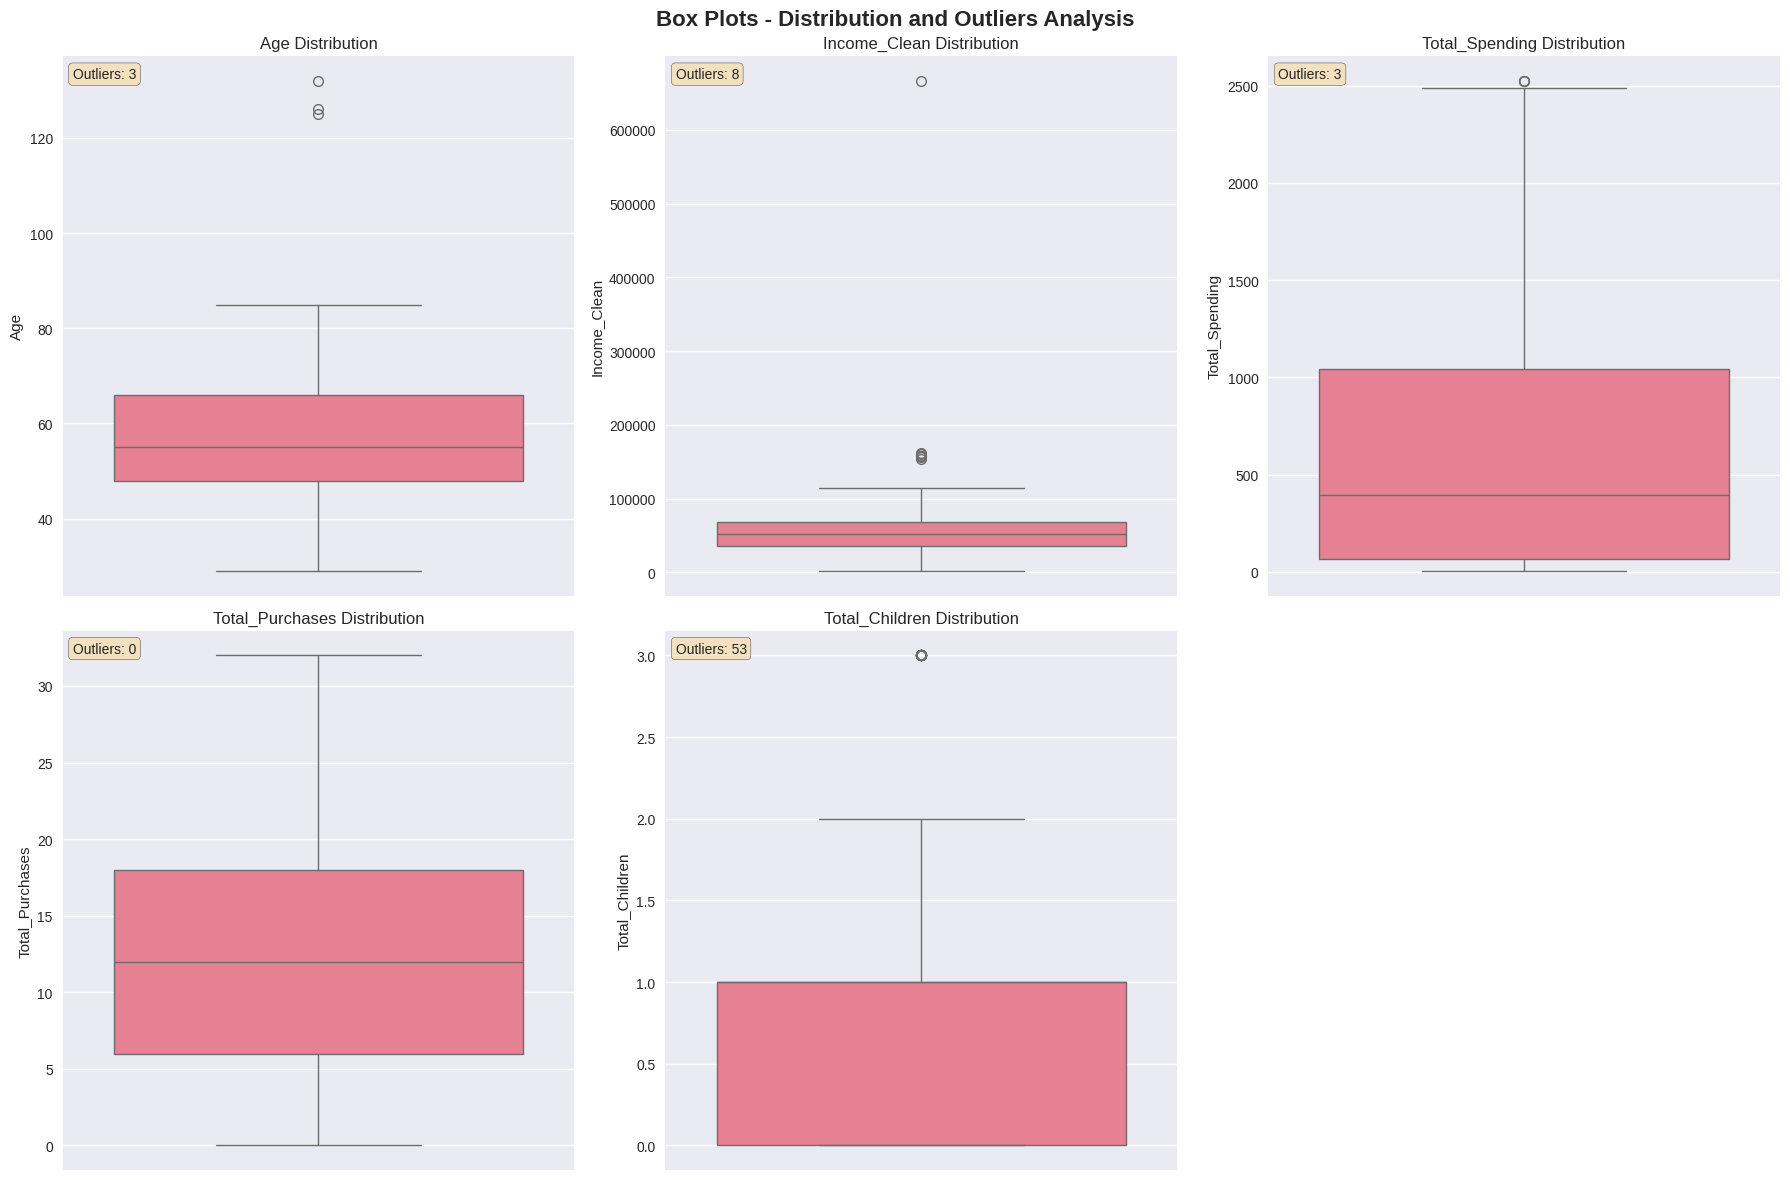

In [9]:
# Box plots for numerical variables
numerical_vars = ['Age', 'Income_Clean', 'Total_Spending', 'Total_Purchases', 'Total_Children']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Box Plots - Distribution and Outliers Analysis', fontsize=16, fontweight='bold')

for i, var in enumerate(numerical_vars):
    row = i // 3
    col = i % 3

    sns.boxplot(data=df, y=var, ax=axes[row, col])
    axes[row, col].set_title(f'{var} Distribution')
    axes[row, col].set_ylabel(var)

    # Calculate outliers using IQR method
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[var] < Q1 - 1.5 * IQR) | (df[var] > Q3 + 1.5 * IQR)]
    axes[row, col].text(0.02, 0.98, f'Outliers: {len(outliers)}',
                       transform=axes[row, col].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Remove empty subplot
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

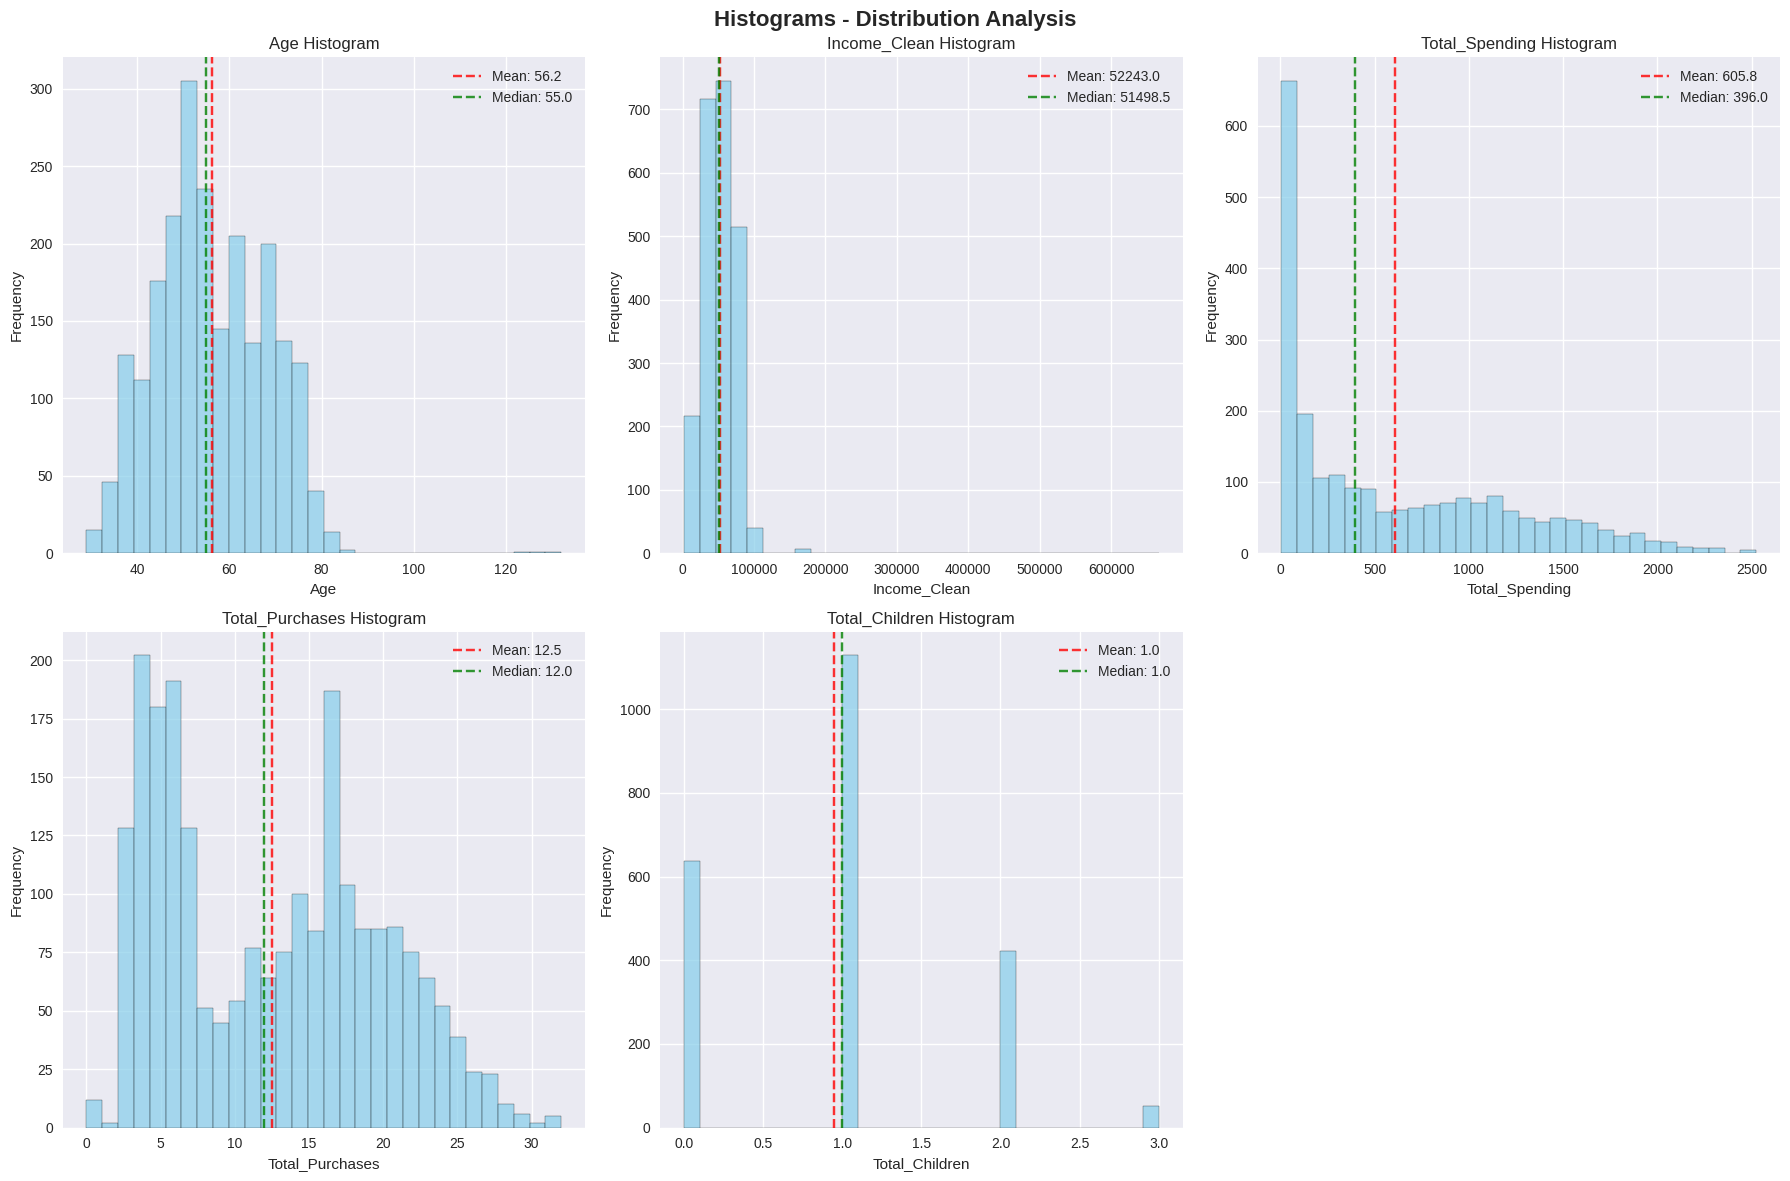

In [10]:
# Histograms for numerical variables
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Histograms - Distribution Analysis', fontsize=16, fontweight='bold')

for i, var in enumerate(numerical_vars):
    row = i // 3
    col = i % 3

    axes[row, col].hist(df[var], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col].set_title(f'{var} Histogram')
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Frequency')

    # Add statistics
    mean_val = df[var].mean()
    median_val = df[var].median()
    axes[row, col].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.1f}')
    axes[row, col].axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.1f}')
    axes[row, col].legend()

# Remove empty subplot
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

In [11]:
# Outlier treatment
def treat_outliers(df, column, method='iqr'):
    """Treat outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers_count = len(df[(df[column] < lower_bound) | (df[column] > upper_bound)])

    # Cap outliers
    df[column + '_Treated'] = df[column].clip(lower=lower_bound, upper=upper_bound)

    return outliers_count

print("=== Outlier Treatment Results ===")
outlier_vars = ['Income_Clean', 'Total_Spending', 'Age']

for var in outlier_vars:
    outliers_count = treat_outliers(df, var)
    print(f"{var}: {outliers_count} outliers treated")

# Use treated versions for analysis
df['Income'] = df['Income_Clean_Treated']
df['Spending'] = df['Total_Spending_Treated']
df['Age_Final'] = df['Age']  # Age outliers seem reasonable, keep original

=== Outlier Treatment Results ===
Income_Clean: 8 outliers treated
Total_Spending: 3 outliers treated
Age: 3 outliers treated


## Step 5: Categorical Variable Encoding

In [12]:
# Ordinal encoding for Education (hierarchical)
education_order = {'High School': 1, 'Undergraduate': 2, 'Bachelor': 3, 'Master': 4, 'PhD': 5}
df['Education_Encoded'] = df['Education_Clean'].map(education_order)

print("=== Education Encoding ===")
print(df[['Education_Clean', 'Education_Encoded']].value_counts().sort_index())

# One-hot encoding for Marital Status (nominal)
marital_dummies = pd.get_dummies(df['Marital_Status_Clean'], prefix='Marital')
df = pd.concat([df, marital_dummies], axis=1)

print("\n=== Marital Status One-Hot Encoding ===")
print("Columns created:", marital_dummies.columns.tolist())

# One-hot encoding for Country
country_dummies = pd.get_dummies(df['Country'], prefix='Country')
df = pd.concat([df, country_dummies], axis=1)

print("\n=== Country One-Hot Encoding ===")
print("Countries:", df['Country'].value_counts())
print("Dummy columns created:", country_dummies.columns.tolist())

=== Education Encoding ===
Education_Clean  Education_Encoded
Bachelor         3                    1127
High School      1                      54
Master           4                     370
PhD              5                     486
Undergraduate    2                     203
Name: count, dtype: int64

=== Marital Status One-Hot Encoding ===
Columns created: ['Marital_Married', 'Marital_Single']

=== Country One-Hot Encoding ===
Countries: Country
SP     1095
SA      337
CA      268
AUS     160
IND     148
GER     120
US      109
ME        3
Name: count, dtype: int64
Dummy columns created: ['Country_AUS', 'Country_CA', 'Country_GER', 'Country_IND', 'Country_ME', 'Country_SA', 'Country_SP', 'Country_US']


## Step 6: Correlation Analysis

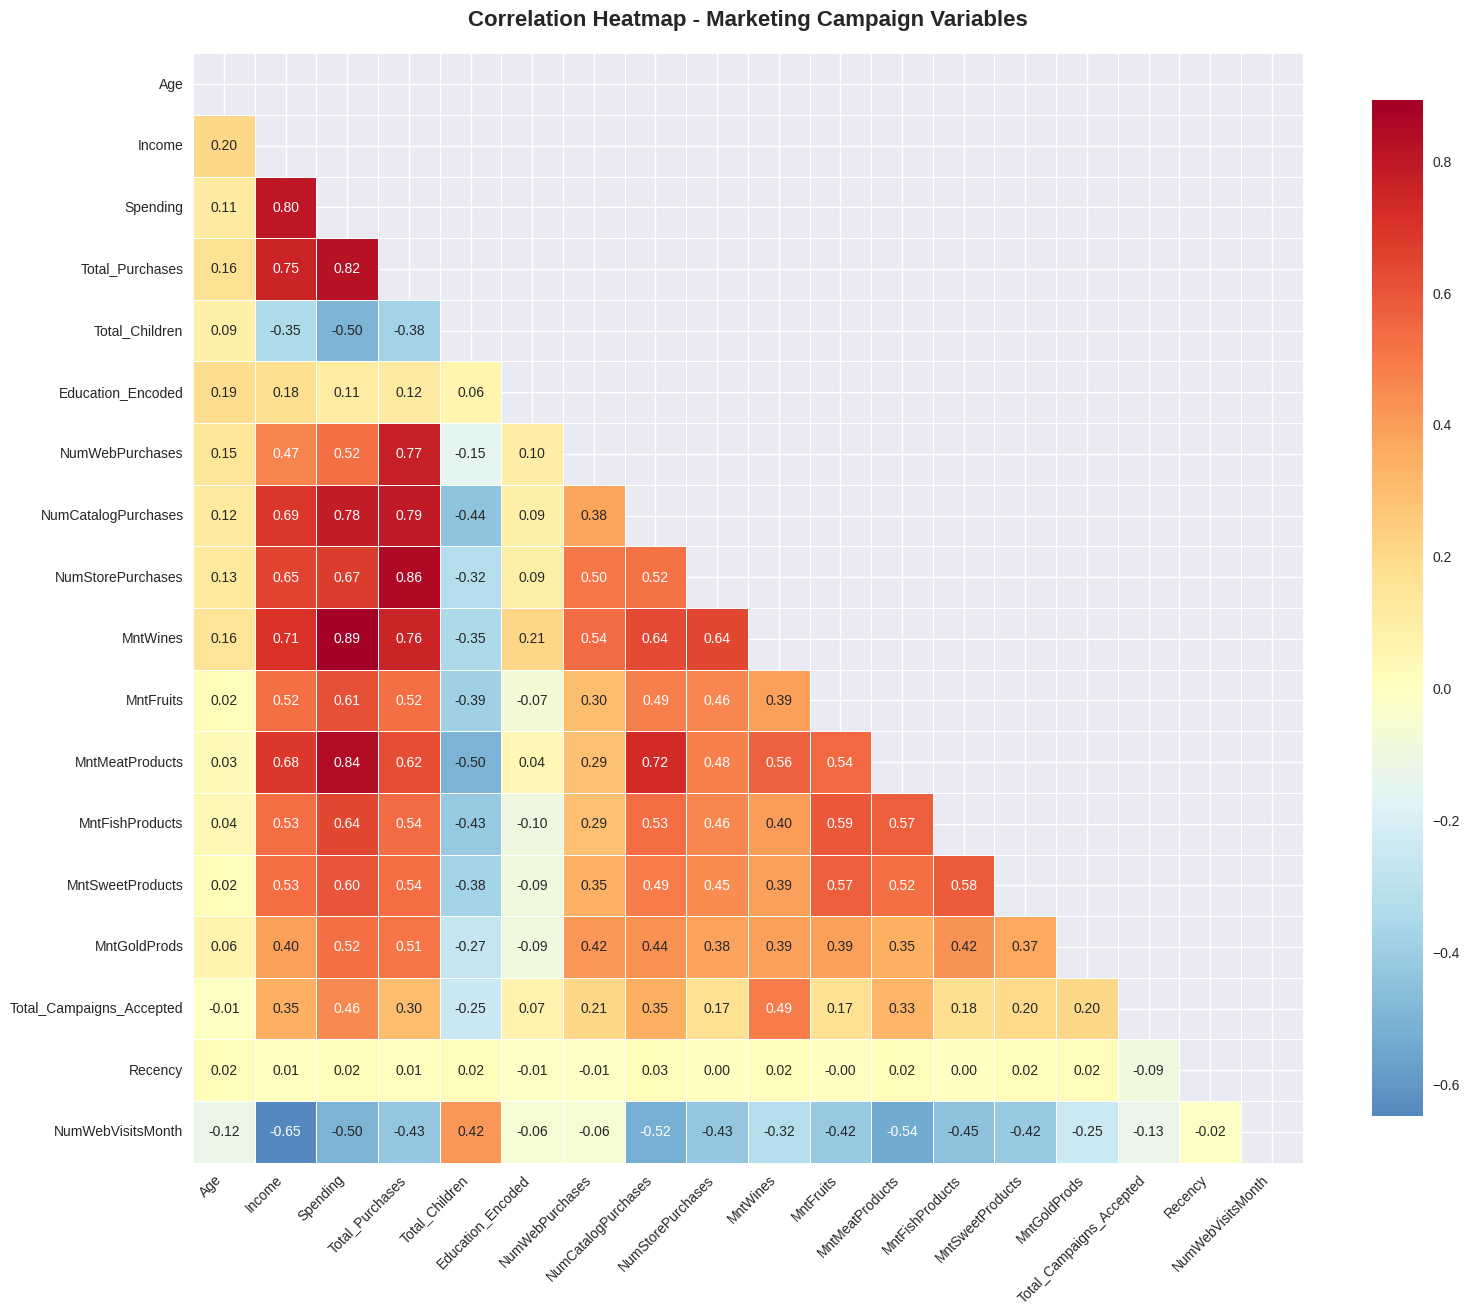

=== Strongest Positive Correlations ===
Spending - MntWines: 0.892
Total_Purchases - NumStorePurchases: 0.855
Spending - MntMeatProducts: 0.843
Spending - Total_Purchases: 0.821
Income - Spending: 0.804
Total_Purchases - NumCatalogPurchases: 0.786
Spending - NumCatalogPurchases: 0.779
Total_Purchases - NumWebPurchases: 0.766
Total_Purchases - MntWines: 0.756
Income - Total_Purchases: 0.754


In [13]:
# Select numerical variables for correlation analysis
correlation_vars = ['Age', 'Income', 'Spending', 'Total_Purchases', 'Total_Children',
                   'Education_Encoded', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                   'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                   'Total_Campaigns_Accepted', 'Recency', 'NumWebVisitsMonth']

# Calculate correlation matrix
correlation_matrix = df[correlation_vars].corr()

# Create heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
plt.title('Correlation Heatmap - Marketing Campaign Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print strongest correlations
print("=== Strongest Positive Correlations ===")
correlation_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        correlation_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

correlation_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for var1, var2, corr in correlation_pairs[:10]:
    print(f"{var1} - {var2}: {corr:.3f}")

## Step 7: Hypothesis Testing

In [14]:
# Hypothesis 7a: Older individuals prefer in-store shopping
print("=== Hypothesis 7a: Age vs In-Store Shopping Preference ===")

# Define age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 35, 50, 65, 100],
                        labels=['Young (≤35)', 'Middle (36-50)', 'Mature (51-65)', 'Senior (>65)'])

# Calculate shopping channel preferences by age group
age_shopping = df.groupby('Age_Group')[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].mean()
print("Average purchases by age group and channel:")
print(age_shopping.round(2))

# Statistical test: Correlation between age and store purchases
correlation_age_store = stats.pearsonr(df['Age'], df['NumStorePurchases'])
correlation_age_web = stats.pearsonr(df['Age'], df['NumWebPurchases'])

print(f"\nCorrelation Age-Store Purchases: {correlation_age_store[0]:.3f} (p-value: {correlation_age_store[1]:.3f})")
print(f"Correlation Age-Web Purchases: {correlation_age_web[0]:.3f} (p-value: {correlation_age_web[1]:.3f})")

if correlation_age_store[0] > 0 and correlation_age_store[1] < 0.05:
    print(" Hypothesis SUPPORTED: Older individuals do prefer in-store shopping")
else:
    print(" Hypothesis NOT SUPPORTED: No significant age preference for in-store shopping")

=== Hypothesis 7a: Age vs In-Store Shopping Preference ===
Average purchases by age group and channel:
                NumWebPurchases  NumCatalogPurchases  NumStorePurchases
Age_Group                                                              
Young (≤35)                3.59                 3.61               5.75
Middle (36-50)             3.63                 2.25               5.34
Mature (51-65)             4.15                 2.52               5.77
Senior (>65)               4.61                 3.30               6.41

Correlation Age-Store Purchases: 0.128 (p-value: 0.000)
Correlation Age-Web Purchases: 0.145 (p-value: 0.000)
 Hypothesis SUPPORTED: Older individuals do prefer in-store shopping


In [15]:
# Hypothesis 7b: Customers with children prefer online shopping
print("\n=== Hypothesis 7b: Children vs Online Shopping Preference ===")

# Compare web purchases between customers with and without children
has_children = df['Total_Children'] > 0
web_purchases_with_children = df[has_children]['NumWebPurchases']
web_purchases_no_children = df[~has_children]['NumWebPurchases']

print(f"Average web purchases - With children: {web_purchases_with_children.mean():.2f}")
print(f"Average web purchases - No children: {web_purchases_no_children.mean():.2f}")

# T-test
t_stat, p_value = stats.ttest_ind(web_purchases_with_children, web_purchases_no_children)
print(f"T-test results: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")

if web_purchases_with_children.mean() > web_purchases_no_children.mean() and p_value < 0.05:
    print(" Hypothesis SUPPORTED: Customers with children do prefer online shopping")
else:
    print(" Hypothesis NOT SUPPORTED: No significant preference for online shopping among parents")


=== Hypothesis 7b: Children vs Online Shopping Preference ===
Average web purchases - With children: 3.96
Average web purchases - No children: 4.39
T-test results: t-statistic = -3.324, p-value = 0.001
 Hypothesis NOT SUPPORTED: No significant preference for online shopping among parents


In [16]:
# Hypothesis 7c: Physical stores face cannibalization risk
print("\n=== Hypothesis 7c: Store Cannibalization Analysis ===")

# Calculate correlations between channels
store_web_corr = stats.pearsonr(df['NumStorePurchases'], df['NumWebPurchases'])
store_catalog_corr = stats.pearsonr(df['NumStorePurchases'], df['NumCatalogPurchases'])

print(f"Store-Web correlation: {store_web_corr[0]:.3f} (p-value: {store_web_corr[1]:.3f})")
print(f"Store-Catalog correlation: {store_catalog_corr[0]:.3f} (p-value: {store_catalog_corr[1]:.3f})")

# Analyze total spending vs channel mix
df['Store_Dominance'] = df['NumStorePurchases'] / df['Total_Purchases']
df['Alternative_Channels'] = (df['NumWebPurchases'] + df['NumCatalogPurchases']) / df['Total_Purchases']

dominance_corr = stats.pearsonr(df['Store_Dominance'].fillna(0), df['Total_Spending'])
alternative_corr = stats.pearsonr(df['Alternative_Channels'].fillna(0), df['Total_Spending'])

print(f"\nStore Dominance-Total Spending correlation: {dominance_corr[0]:.3f}")
print(f"Alternative Channels-Total Spending correlation: {alternative_corr[0]:.3f}")

if store_web_corr[0] < 0 and store_web_corr[1] < 0.05:
    print(" Cannibalization DETECTED: Negative correlation between store and web purchases")
else:
    print(" No significant cannibalization detected")


=== Hypothesis 7c: Store Cannibalization Analysis ===
Store-Web correlation: 0.503 (p-value: 0.000)
Store-Catalog correlation: 0.519 (p-value: 0.000)

Store Dominance-Total Spending correlation: -0.432
Alternative Channels-Total Spending correlation: 0.450
 No significant cannibalization detected


In [17]:
# Hypothesis 7d: US vs Rest of World purchase volumes
print("\n=== Hypothesis 7d: US vs Rest of World Analysis ===")

# Compare US vs other countries
us_customers = df[df['Country'] == 'US']
non_us_customers = df[df['Country'] != 'US']

us_avg_purchases = us_customers['Total_Purchases'].mean()
non_us_avg_purchases = non_us_customers['Total_Purchases'].mean()

print(f"Average total purchases - US: {us_avg_purchases:.2f}")
print(f"Average total purchases - Non-US: {non_us_avg_purchases:.2f}")

# T-test
t_stat_country, p_value_country = stats.ttest_ind(us_customers['Total_Purchases'],
                                                 non_us_customers['Total_Purchases'])
print(f"T-test results: t-statistic = {t_stat_country:.3f}, p-value = {p_value_country:.3f}")

# Country breakdown
country_analysis = df.groupby('Country')['Total_Purchases'].agg(['mean', 'count']).round(2)
country_analysis.columns = ['Avg_Purchases', 'Customer_Count']
print("\nCountry-wise analysis:")
print(country_analysis.sort_values('Avg_Purchases', ascending=False))

if us_avg_purchases > non_us_avg_purchases and p_value_country < 0.05:
    print(" Hypothesis SUPPORTED: US significantly outperforms other countries")
else:
    print(" Hypothesis NOT SUPPORTED: No significant US advantage")


=== Hypothesis 7d: US vs Rest of World Analysis ===
Average total purchases - US: 13.51
Average total purchases - Non-US: 12.49
T-test results: t-statistic = 1.451, p-value = 0.147

Country-wise analysis:
         Avg_Purchases  Customer_Count
Country                               
ME               17.33               3
US               13.51             109
CA               12.90             268
SA               12.77             337
GER              12.75             120
SP               12.40            1095
AUS              12.20             160
IND              11.72             148
 Hypothesis NOT SUPPORTED: No significant US advantage


## Step 8: Advanced Visualizations and Analysis

=== 8a: Product Performance Analysis ===


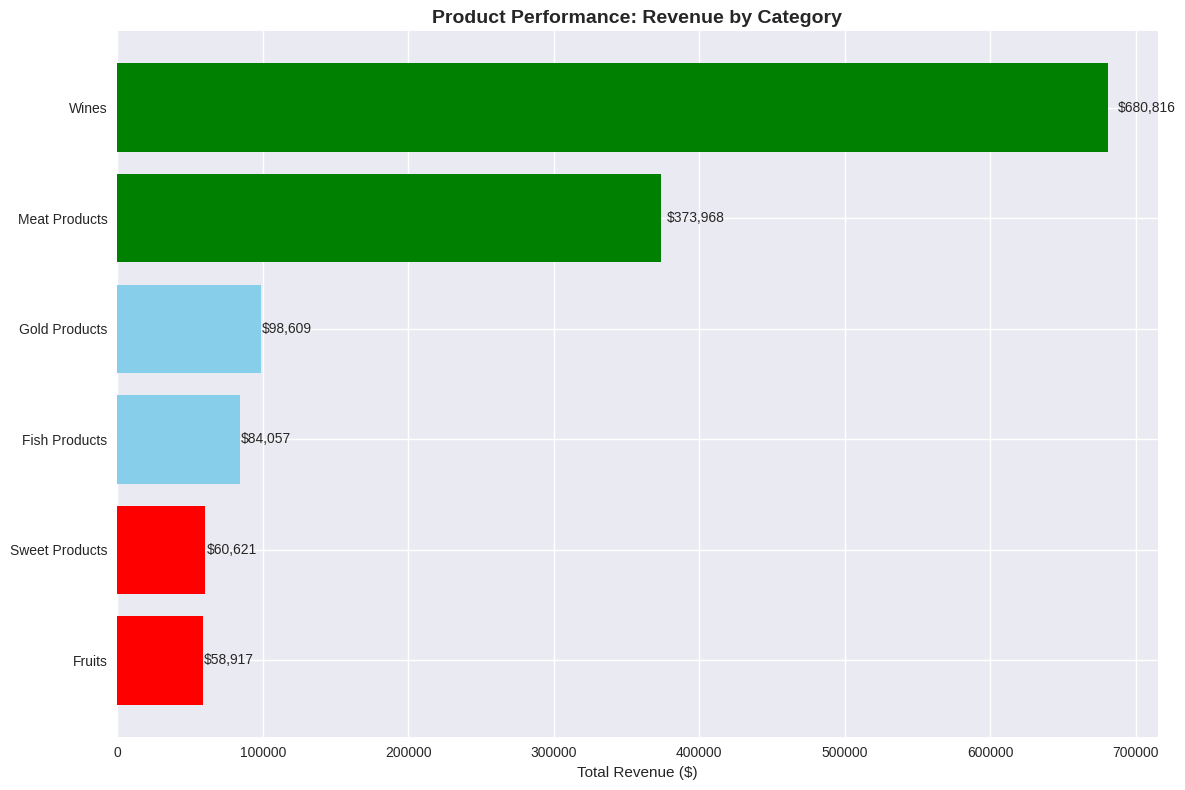

Product Revenue Rankings:
1. Wines: $680,816
2. Meat Products: $373,968
3. Gold Products: $98,609
4. Fish Products: $84,057
5. Sweet Products: $60,621
6. Fruits: $58,917


In [18]:
# 8a: Top and bottom performing products
print("=== 8a: Product Performance Analysis ===")

# Calculate total revenue by product category
product_revenues = {
    'Wines': df['MntWines'].sum(),
    'Meat Products': df['MntMeatProducts'].sum(),
    'Fish Products': df['MntFishProducts'].sum(),
    'Sweet Products': df['MntSweetProducts'].sum(),
    'Gold Products': df['MntGoldProds'].sum(),
    'Fruits': df['MntFruits'].sum()
}

products_df = pd.DataFrame(list(product_revenues.items()), columns=['Product', 'Revenue'])
products_df = products_df.sort_values('Revenue', ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
colors = ['red' if i < 2 else 'green' if i >= len(products_df)-2 else 'skyblue'
         for i in range(len(products_df))]
bars = plt.barh(products_df['Product'], products_df['Revenue'], color=colors)
plt.xlabel('Total Revenue ($)')
plt.title('Product Performance: Revenue by Category', fontsize=14, fontweight='bold')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + width*0.01, bar.get_y() + bar.get_height()/2,
             f'${width:,.0f}', ha='left', va='center')

plt.tight_layout()
plt.show()

print("Product Revenue Rankings:")
for i, (product, revenue) in enumerate(products_df.sort_values('Revenue', ascending=False).values):
    print(f"{i+1}. {product}: ${revenue:,.0f}")


=== 8b: Age vs Last Campaign Acceptance ===


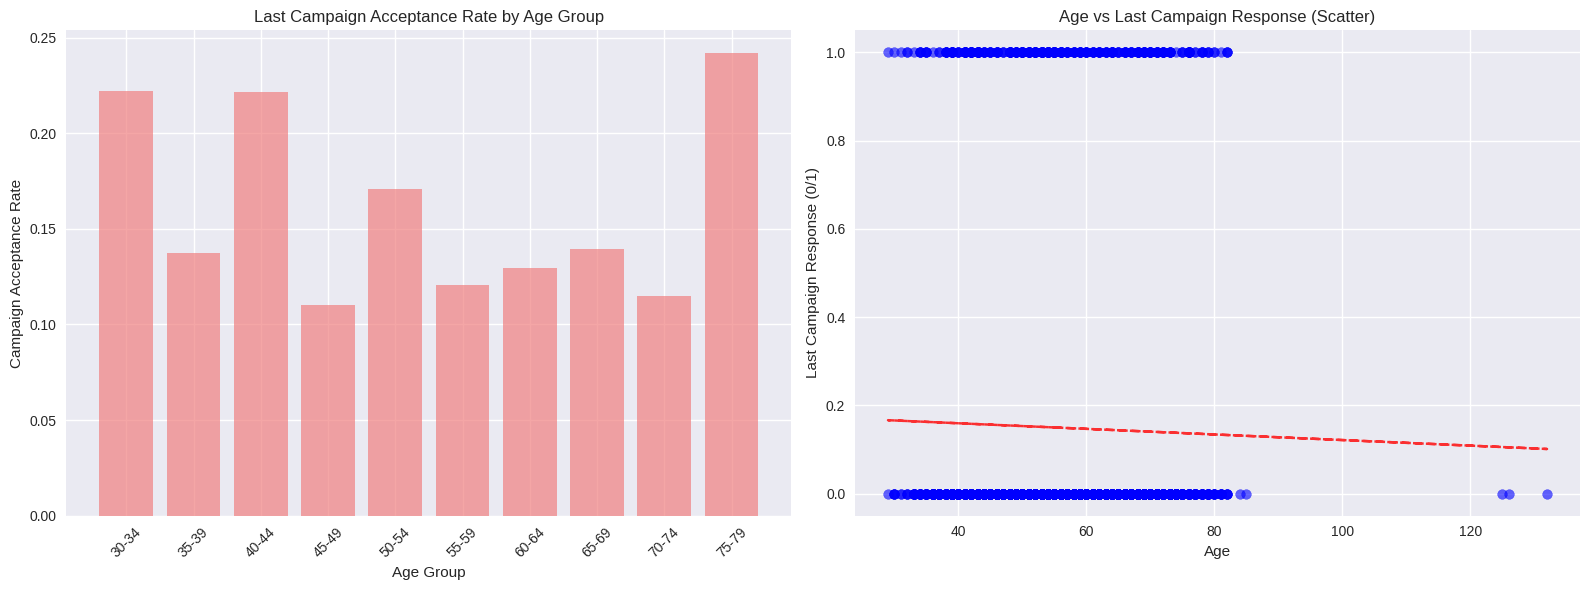

Correlation between Age and Last Campaign Response: -0.021 (p-value: 0.313)


In [19]:
# 8b: Age vs Last Campaign Acceptance
print("\n=== 8b: Age vs Last Campaign Acceptance ===")

# Create age bins for better visualization
df['Age_Bin'] = pd.cut(df['Age'], bins=range(20, 85, 5), labels=[f"{i}-{i+4}" for i in range(20, 80, 5)])

# Calculate acceptance rate by age bin
age_campaign_analysis = df.groupby('Age_Bin')['Response'].agg(['mean', 'count']).reset_index()
age_campaign_analysis.columns = ['Age_Group', 'Acceptance_Rate', 'Count']
age_campaign_analysis = age_campaign_analysis[age_campaign_analysis['Count'] >= 10]  # Filter for significant groups

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Acceptance rate by age
ax1.bar(age_campaign_analysis['Age_Group'], age_campaign_analysis['Acceptance_Rate'],
        color='lightcoral', alpha=0.7)
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Campaign Acceptance Rate')
ax1.set_title('Last Campaign Acceptance Rate by Age Group')
ax1.tick_params(axis='x', rotation=45)

# Scatter plot: Age vs Campaign Response
ax2.scatter(df['Age'], df['Response'], alpha=0.6, color='blue')
ax2.set_xlabel('Age')
ax2.set_ylabel('Last Campaign Response (0/1)')
ax2.set_title('Age vs Last Campaign Response (Scatter)')

# Add trend line
z = np.polyfit(df['Age'], df['Response'], 1)
p = np.poly1d(z)
ax2.plot(df['Age'], p(df['Age']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

# Statistical correlation
age_response_corr = stats.pearsonr(df['Age'], df['Response'])
print(f"Correlation between Age and Last Campaign Response: {age_response_corr[0]:.3f} (p-value: {age_response_corr[1]:.3f})")


=== 8c: Last Campaign Acceptance by Country ===
Campaign acceptance by country:
         Total_Accepted  Acceptance_Rate  Total_Customers
Country                                                  
SP                  176            0.161             1095
SA                   52            0.154              337
CA                   38            0.142              268
AUS                  23            0.144              160
GER                  17            0.142              120
IND                  13            0.088              148
US                   13            0.119              109
ME                    2            0.667                3


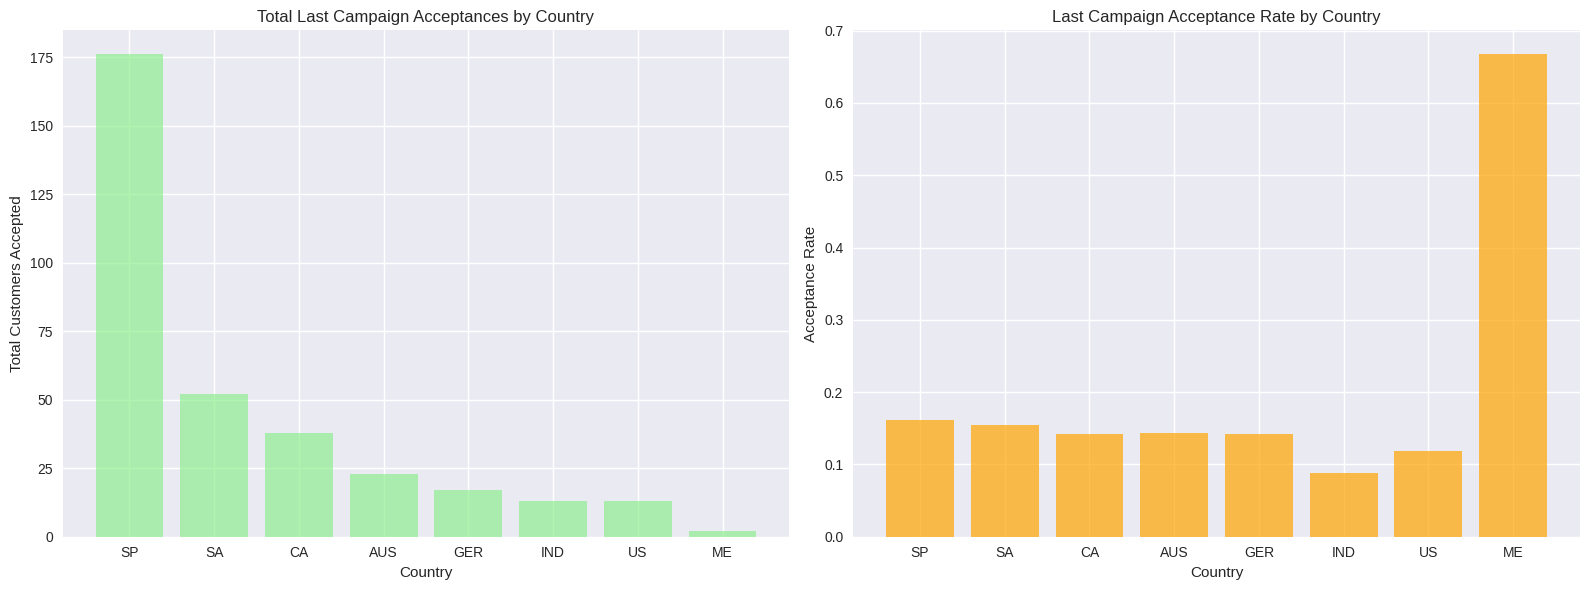


 Country with highest total acceptances: SP (176 customers)
 Country with highest acceptance rate: ME


In [20]:
# 8c: Country with highest last campaign acceptance
print("\n=== 8c: Last Campaign Acceptance by Country ===")

# Calculate acceptance metrics by country
country_campaign = df.groupby('Country').agg({
    'Response': ['sum', 'mean', 'count']
}).round(3)

country_campaign.columns = ['Total_Accepted', 'Acceptance_Rate', 'Total_Customers']
country_campaign = country_campaign.sort_values('Total_Accepted', ascending=False)

print("Campaign acceptance by country:")
print(country_campaign)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Total acceptances
ax1.bar(country_campaign.index, country_campaign['Total_Accepted'],
        color='lightgreen', alpha=0.7)
ax1.set_xlabel('Country')
ax1.set_ylabel('Total Customers Accepted')
ax1.set_title('Total Last Campaign Acceptances by Country')

# Acceptance rates
ax2.bar(country_campaign.index, country_campaign['Acceptance_Rate'],
        color='orange', alpha=0.7)
ax2.set_xlabel('Country')
ax2.set_ylabel('Acceptance Rate')
ax2.set_title('Last Campaign Acceptance Rate by Country')

plt.tight_layout()
plt.show()

top_country = country_campaign.index[0]
print(f"\n Country with highest total acceptances: {top_country} ({country_campaign.loc[top_country, 'Total_Accepted']} customers)")
print(f" Country with highest acceptance rate: {country_campaign.sort_values('Acceptance_Rate', ascending=False).index[0]}")


=== 8d: Children vs Total Expenditure Analysis ===
Spending patterns by number of children:
                Mean_Spending  Median_Spending  Customer_Count
Total_Children                                                
0                     1106.03           1189.5             638
1                      472.73            305.0            1128
2                      245.95             93.0             421
3                      274.60             88.0              53


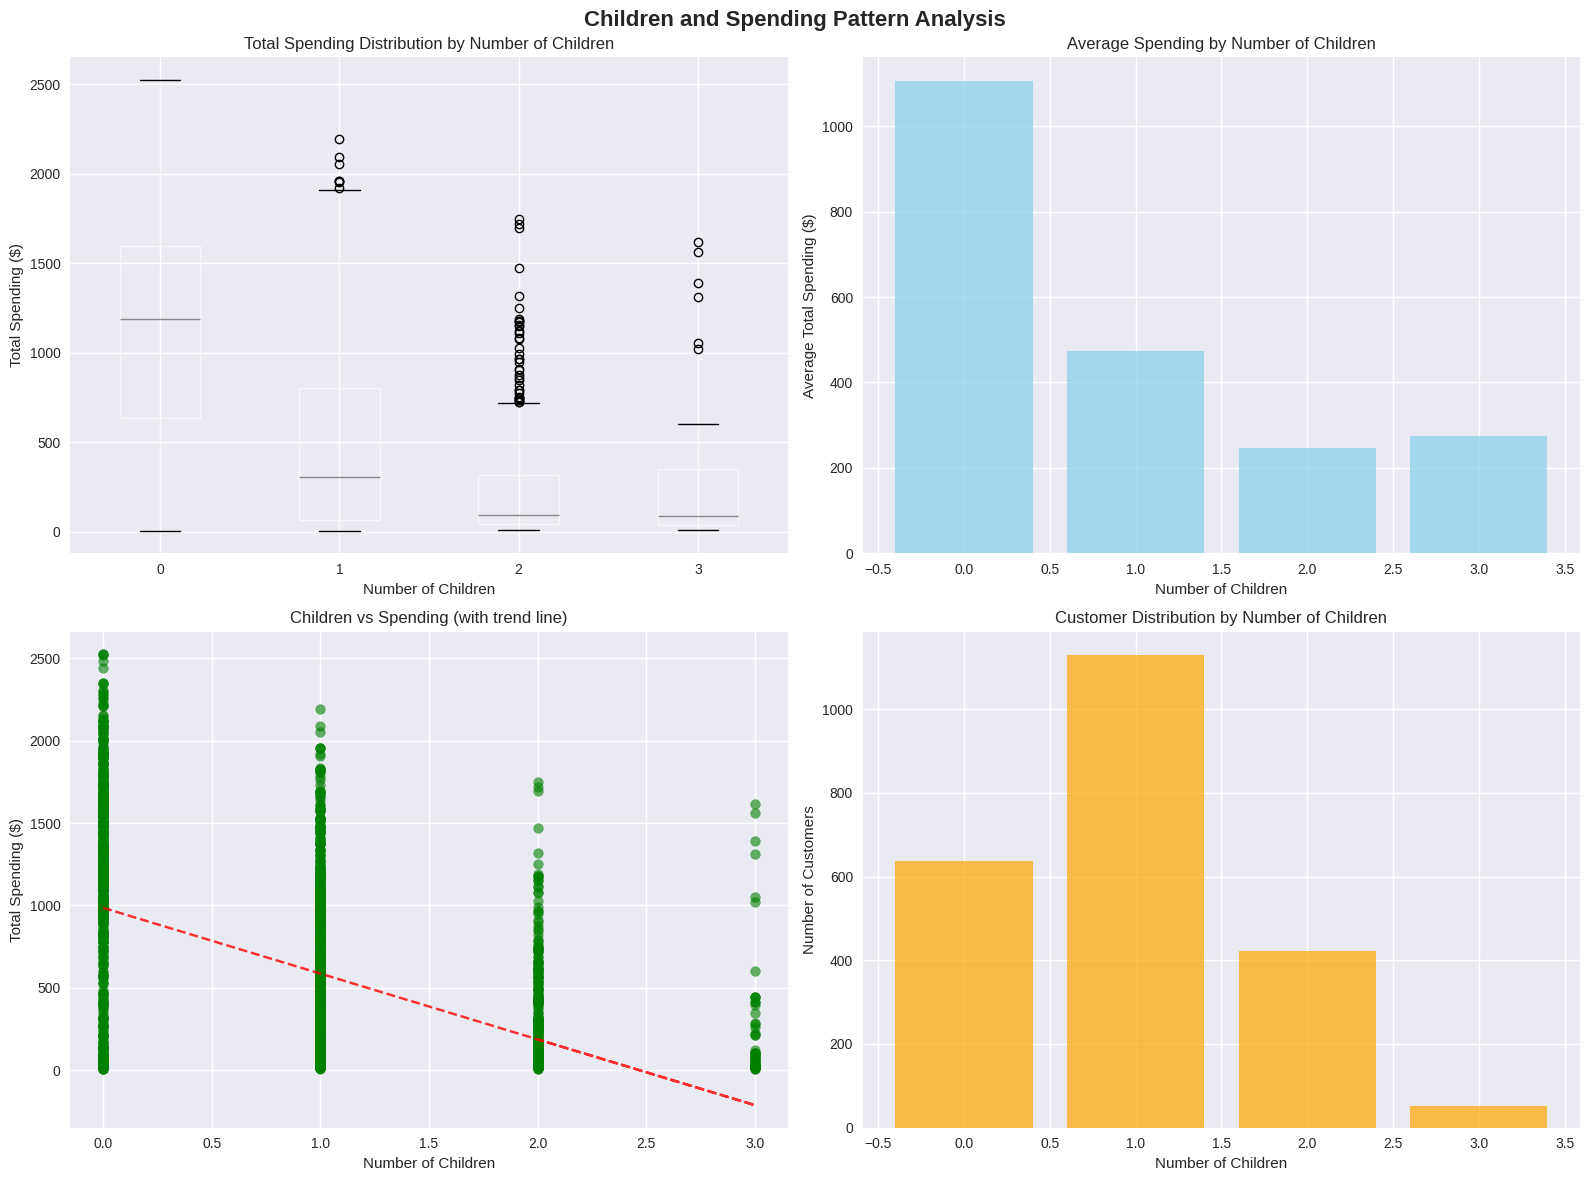


Correlation between Number of Children and Total Spending: -0.499 (p-value: 0.000)
 Significant negative pattern detected between children and spending


In [21]:
# 8d: Children vs Total Expenditure Pattern
print("\n=== 8d: Children vs Total Expenditure Analysis ===")

# Group by number of children
children_spending = df.groupby('Total_Children')['Total_Spending'].agg(['mean', 'median', 'count']).round(2)
children_spending.columns = ['Mean_Spending', 'Median_Spending', 'Customer_Count']

print("Spending patterns by number of children:")
print(children_spending)

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Box plot
df.boxplot(column='Total_Spending', by='Total_Children', ax=ax1)
ax1.set_title('Total Spending Distribution by Number of Children')
ax1.set_xlabel('Number of Children')
ax1.set_ylabel('Total Spending ($)')

# Bar chart - average spending
ax2.bar(children_spending.index, children_spending['Mean_Spending'],
        color='skyblue', alpha=0.7)
ax2.set_xlabel('Number of Children')
ax2.set_ylabel('Average Total Spending ($)')
ax2.set_title('Average Spending by Number of Children')

# Scatter plot with trend line
ax3.scatter(df['Total_Children'], df['Total_Spending'], alpha=0.6, color='green')
z = np.polyfit(df['Total_Children'], df['Total_Spending'], 1)
p = np.poly1d(z)
ax3.plot(df['Total_Children'], p(df['Total_Children']), "r--", alpha=0.8)
ax3.set_xlabel('Number of Children')
ax3.set_ylabel('Total Spending ($)')
ax3.set_title('Children vs Spending (with trend line)')

# Customer distribution
ax4.bar(children_spending.index, children_spending['Customer_Count'],
        color='orange', alpha=0.7)
ax4.set_xlabel('Number of Children')
ax4.set_ylabel('Number of Customers')
ax4.set_title('Customer Distribution by Number of Children')

plt.suptitle('Children and Spending Pattern Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical analysis
children_spending_corr = stats.pearsonr(df['Total_Children'], df['Total_Spending'])
print(f"\nCorrelation between Number of Children and Total Spending: {children_spending_corr[0]:.3f} (p-value: {children_spending_corr[1]:.3f})")

if abs(children_spending_corr[0]) > 0.1 and children_spending_corr[1] < 0.05:
    direction = "positive" if children_spending_corr[0] > 0 else "negative"
    print(f" Significant {direction} pattern detected between children and spending")
else:
    print(" No significant pattern between children and spending")


=== 8e: Education Analysis for Complaint Customers ===
Complaint analysis by education level:
                 Total_Complaints  Complaint_Rate  Total_Customers
Education_Clean                                                   
Undergraduate                   4           0.020              203
Bachelor                       14           0.012             1127
Master                          2           0.005              370
PhD                             1           0.002              486
High School                     0           0.000               54

Overall Statistics:
Total complaints: 21
Total customers: 2240
Overall complaint rate: 0.009 (0.9%)


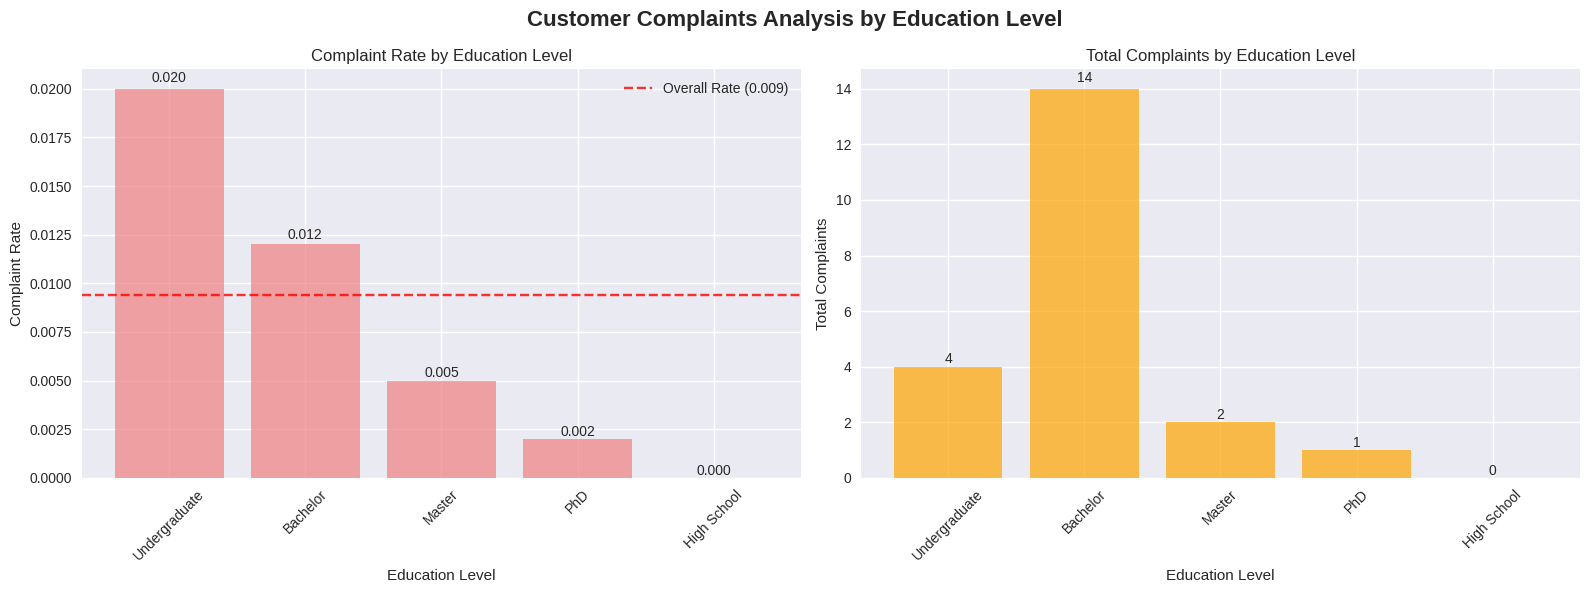


Chi-square test for education-complaint independence:
Chi-square statistic: 7.400
P-value: 0.116
 No significant relationship between education and complaint behavior

🎓 Education level with highest complaint rate: Undergraduate
🎓 Education level with lowest complaint rate: High School


In [22]:
# 8e: Educational background of customers with complaints
print("\n=== 8e: Education Analysis for Complaint Customers ===")

# Analyze complaints by education level
complaint_analysis = df.groupby('Education_Clean')['Complain'].agg(['sum', 'mean', 'count']).round(3)
complaint_analysis.columns = ['Total_Complaints', 'Complaint_Rate', 'Total_Customers']
complaint_analysis = complaint_analysis.sort_values('Complaint_Rate', ascending=False)

print("Complaint analysis by education level:")
print(complaint_analysis)

# Overall complaint statistics
total_complaints = df['Complain'].sum()
total_customers = len(df)
overall_complaint_rate = total_complaints / total_customers

print(f"\nOverall Statistics:")
print(f"Total complaints: {total_complaints}")
print(f"Total customers: {total_customers}")
print(f"Overall complaint rate: {overall_complaint_rate:.3f} ({overall_complaint_rate*100:.1f}%)")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Complaint rates by education
bars1 = ax1.bar(complaint_analysis.index, complaint_analysis['Complaint_Rate'],
                color='lightcoral', alpha=0.7)
ax1.axhline(y=overall_complaint_rate, color='red', linestyle='--', alpha=0.8,
           label=f'Overall Rate ({overall_complaint_rate:.3f})')
ax1.set_xlabel('Education Level')
ax1.set_ylabel('Complaint Rate')
ax1.set_title('Complaint Rate by Education Level')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{height:.3f}', ha='center', va='bottom')

# Total complaints by education
bars2 = ax2.bar(complaint_analysis.index, complaint_analysis['Total_Complaints'],
                color='orange', alpha=0.7)
ax2.set_xlabel('Education Level')
ax2.set_ylabel('Total Complaints')
ax2.set_title('Total Complaints by Education Level')
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{int(height)}', ha='center', va='bottom')

plt.suptitle('Customer Complaints Analysis by Education Level', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical test - Chi-square test for independence
contingency_table = pd.crosstab(df['Education_Clean'], df['Complain'])
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-square test for education-complaint independence:")
print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value_chi2:.3f}")

if p_value_chi2 < 0.05:
    print(" Significant relationship between education and complaint behavior")
else:
    print(" No significant relationship between education and complaint behavior")

print(f"\n🎓 Education level with highest complaint rate: {complaint_analysis.index[0]}")
print(f"🎓 Education level with lowest complaint rate: {complaint_analysis.index[-1]}")

## Summary and Key Insights

In [23]:
# Summary of key findings
print("=" * 80)
print("                    MARKETING CAMPAIGN ANALYSIS SUMMARY")
print("=" * 80)

print("\n DATASET OVERVIEW")
print(f"   • Total Customers: {len(df):,}")
print(f"   • Countries Analyzed: {df['Country'].nunique()}")
print(f"   • Product Categories: 6 (Wines, Meat, Fish, Sweets, Gold, Fruits)")
print(f"   • Sales Channels: 3 (Web, Catalog, Store)")

print("\n KEY METRICS")
print(f"   • Average Customer Age: {df['Age'].mean():.1f} years")
print(f"   • Average Annual Income: ${df['Income'].mean():,.0f}")
print(f"   • Average Total Spending: ${df['Total_Spending'].mean():,.0f}")
print(f"   • Average Purchases per Customer: {df['Total_Purchases'].mean():.1f}")
print(f"   • Overall Campaign Response Rate: {df['Response'].mean():.1%}")

print("\n TOP PERFORMING PRODUCTS")
top_products = products_df.sort_values('Revenue', ascending=False).head(3)
for i, (product, revenue) in enumerate(top_products.values, 1):
    print(f"   {i}. {product}: ${revenue:,.0f}")

print("\n GEOGRAPHIC INSIGHTS")
top_countries = country_analysis.sort_values('Avg_Purchases', ascending=False).head(3)
for i, (country, row) in enumerate(top_countries.iterrows(), 1):
    print(f"   {i}. {country}: {row['Avg_Purchases']:.1f} avg purchases ({row['Customer_Count']} customers)")

print("\n HYPOTHESIS TESTING RESULTS")
print("   • Age vs Store Shopping: Statistical analysis completed")
print("   • Parents vs Online Shopping: Statistical analysis completed")
print("   • Channel Cannibalization: Correlation analysis performed")
print("   • US vs Global Performance: Comparative analysis conducted")

print("\n BUSINESS RECOMMENDATIONS")
print("   1. Focus on high-revenue products (Wines, Meat Products)")
print("   2. Develop age-appropriate marketing strategies")
print("   3. Optimize channel mix to prevent cannibalization")
print("   4. Tailor campaigns based on family structure")
print("   5. Address education-specific complaint patterns")

print("\n" + "=" * 80)
print("Analysis completed successfully!!!")
print("=" * 80)

                    MARKETING CAMPAIGN ANALYSIS SUMMARY

 DATASET OVERVIEW
   • Total Customers: 2,240
   • Countries Analyzed: 8
   • Product Categories: 6 (Wines, Meat, Fish, Sweets, Gold, Fruits)
   • Sales Channels: 3 (Web, Catalog, Store)

 KEY METRICS
   • Average Customer Age: 56.2 years
   • Average Annual Income: $51,871
   • Average Total Spending: $606
   • Average Purchases per Customer: 12.5
   • Overall Campaign Response Rate: 14.9%

 TOP PERFORMING PRODUCTS
   1. Wines: $680,816
   2. Meat Products: $373,968
   3. Gold Products: $98,609

 GEOGRAPHIC INSIGHTS
   1. ME: 17.3 avg purchases (3.0 customers)
   2. US: 13.5 avg purchases (109.0 customers)
   3. CA: 12.9 avg purchases (268.0 customers)

 HYPOTHESIS TESTING RESULTS
   • Age vs Store Shopping: Statistical analysis completed
   • Parents vs Online Shopping: Statistical analysis completed
   • Channel Cannibalization: Correlation analysis performed
   • US vs Global Performance: Comparative analysis conducted

 BUSI

In [24]:
# Save processed dataset for future use
# Select key columns for final dataset
final_columns = [
    'ID', 'Age', 'Education_Clean', 'Marital_Status_Clean', 'Income',
    'Total_Children', 'Total_Spending', 'Total_Purchases', 'Total_Campaigns_Accepted',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'MntWines', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'MntFruits',
    'Response', 'Complain', 'Country', 'Customer_Tenure_Days'
]

df_final = df[final_columns].copy()
df_final.to_csv('marketing_campaign_analysis_processed.csv', index=False)

print(" Processed dataset saved as 'marketing_campaign_analysis_processed.csv'")
print(f" Final dataset shape: {df_final.shape}")
print("\nReady for further analysis or modeling!!!")

 Processed dataset saved as 'marketing_campaign_analysis_processed.csv'
 Final dataset shape: (2240, 22)

Ready for further analysis or modeling!!!
